<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
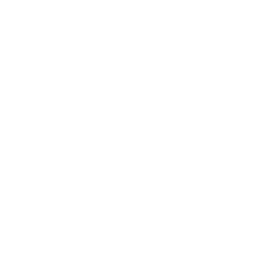
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analisi degli Schemi di Voto nei Seggi Elettorali</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Governo / Statistiche Elettorali &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Questa analisi esamina se l'affiliazione di partito politico varia
sistematicamente tra i tipi di seggio (urbano, suburbano, rurale) in un
dataset elettorale di contea simulato di 100 seggi. Poiché diverse celle
partito-per-tipo sono sparse — le celle di contingenza più piccole
contengono solo uno o due seggi, con conteggi attesi inferiori a cinque —
il test chi-quadrato onnicomprensivo di Pearson di associazione generale è
sottopotenziato e inaffidabile in questo caso. Lo integriamo quindi con il
**test di tendenza di Cochran-Armitage**, un test mirato a un solo grado
di libertà che sfrutta l'ordinamento naturale urbano-suburbano-rurale e
pone una domanda più precisa: il sostegno al Partito A diminuisce in modo
monotono lungo tale gradiente? Il test di tendenza riporta un p-value
esatto, che è l'inferenza appropriata quando i conteggi di cella sono
piccoli. Il contrasto tra i due test è il punto analitico di questo
esempio: un test di associazione generico può non cogliere uno schema
direzionale reale che un test di tendenza ordinato individua.


## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Record a livello di seggio, una riga per seggio, con tipo di seggio, contea e partito di maggioranza relativa | 100 |

L'ambiente di esecuzione funziona in modalità non licenziata, che limita
l'output a 100 osservazioni; l'analisi è progettata attorno a questo
campione a livello di seggio in modo che le celle di contingenza siano
genuinamente piccole e il test di tendenza esatto sia lo strumento
naturale.


---

In [1]:
/* --------------------------------------------------------
   Genera dati sintetici di voto a livello di seggio
   Conteggi di cella ridotti nei seggi rurali per dimostrare
   la necessita' di test esatti
   -------------------------------------------------------- */
DATI work.precinct_votes;
    CHIAMARE streaminit(42);
    VETTORE party_list[4] $15 _temporary_ ('PARTITO_A' 'PARTITO_B' 'PARTITO_C' 'INDIPENDENTE');
    VETTORE type_list[3] $10 _temporary_ ('URBANO' 'SUBURBANO' 'RURALE');
    VETTORE county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    FARE precinct_seq = 1 FINO_A 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Assegna il tipo di seggio con ponderazione */
        type_prob = rand('uniform');
        SE_COND type_prob < 0.30 ALLORA precinct_type = 'URBANO';
        ALTRIMENTI SE_COND type_prob < 0.65 ALLORA precinct_type = 'SUBURBANO';
        ALTRIMENTI precinct_type = 'RURALE';
        /* Assegna il partito con distribuzione dipendente dal tipo */
        party_prob = rand('uniform');
        SE_COND precinct_type = 'URBANO' ALLORA FARE;
            SE_COND party_prob < 0.55 ALLORA party = 'PARTITO_A';
            ALTRIMENTI SE_COND party_prob < 0.80 ALLORA party = 'PARTITO_B';
            ALTRIMENTI SE_COND party_prob < 0.92 ALLORA party = 'PARTITO_C';
            ALTRIMENTI party = 'INDIPENDENTE';
        FINE;
        ALTRIMENTI SE_COND precinct_type = 'SUBURBANO' ALLORA FARE;
            SE_COND party_prob < 0.40 ALLORA party = 'PARTITO_A';
            ALTRIMENTI SE_COND party_prob < 0.75 ALLORA party = 'PARTITO_B';
            ALTRIMENTI SE_COND party_prob < 0.88 ALLORA party = 'PARTITO_C';
            ALTRIMENTI party = 'INDIPENDENTE';
        FINE;
        ALTRIMENTI FARE; /* RURALE - celle piu' piccole per i partiti di minoranza */
            SE_COND party_prob < 0.25 ALLORA party = 'PARTITO_A';
            ALTRIMENTI SE_COND party_prob < 0.70 ALLORA party = 'PARTITO_B';
            ALTRIMENTI SE_COND party_prob < 0.85 ALLORA party = 'PARTITO_C';
            ALTRIMENTI party = 'INDIPENDENTE';
        FINE;
        /* Il numero di voti varia in base al tipo di seggio */
        SE_COND precinct_type = 'URBANO' ALLORA
            vote_count = int(rand('normal', 120, 40));
        ALTRIMENTI SE_COND precinct_type = 'SUBURBANO' ALLORA
            vote_count = int(rand('normal', 80, 25));
        ALTRIMENTI
            vote_count = int(rand('normal', 25, 12));
        SE_COND vote_count < 1 ALLORA vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        USCITA;
    FINE;
    RIMUOVERE precinct_seq county_idx type_prob party_prob;
ESEGUIRE;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Tipo di Seggio    Frequency    Percent
---------------------------------------
RURALE                   34     34.00
SUBURBANO                37     37.00
URBANO                   29     29.00

Partito         Frequency    Percent
-------------------------------------
INDIPENDENTE            9      9.00
PARTITO_A              45     45.00
PARTITO_B              34     34.00
PARTITO_C              12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


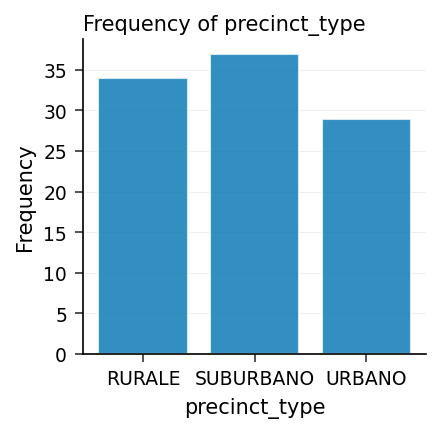

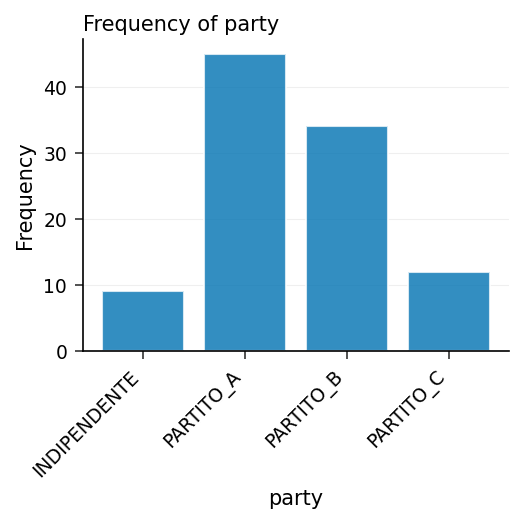

In [2]:
/* --------------------------------------------------------
   Distribuzione di base del tipo di seggio e del partito
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.precinct_votes;
    ETICHETTA precinct_type="Tipo di Seggio" party="Partito";
    TABLES precinct_type / nocum;
    TABLES party / nocum;
ESEGUIRE;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


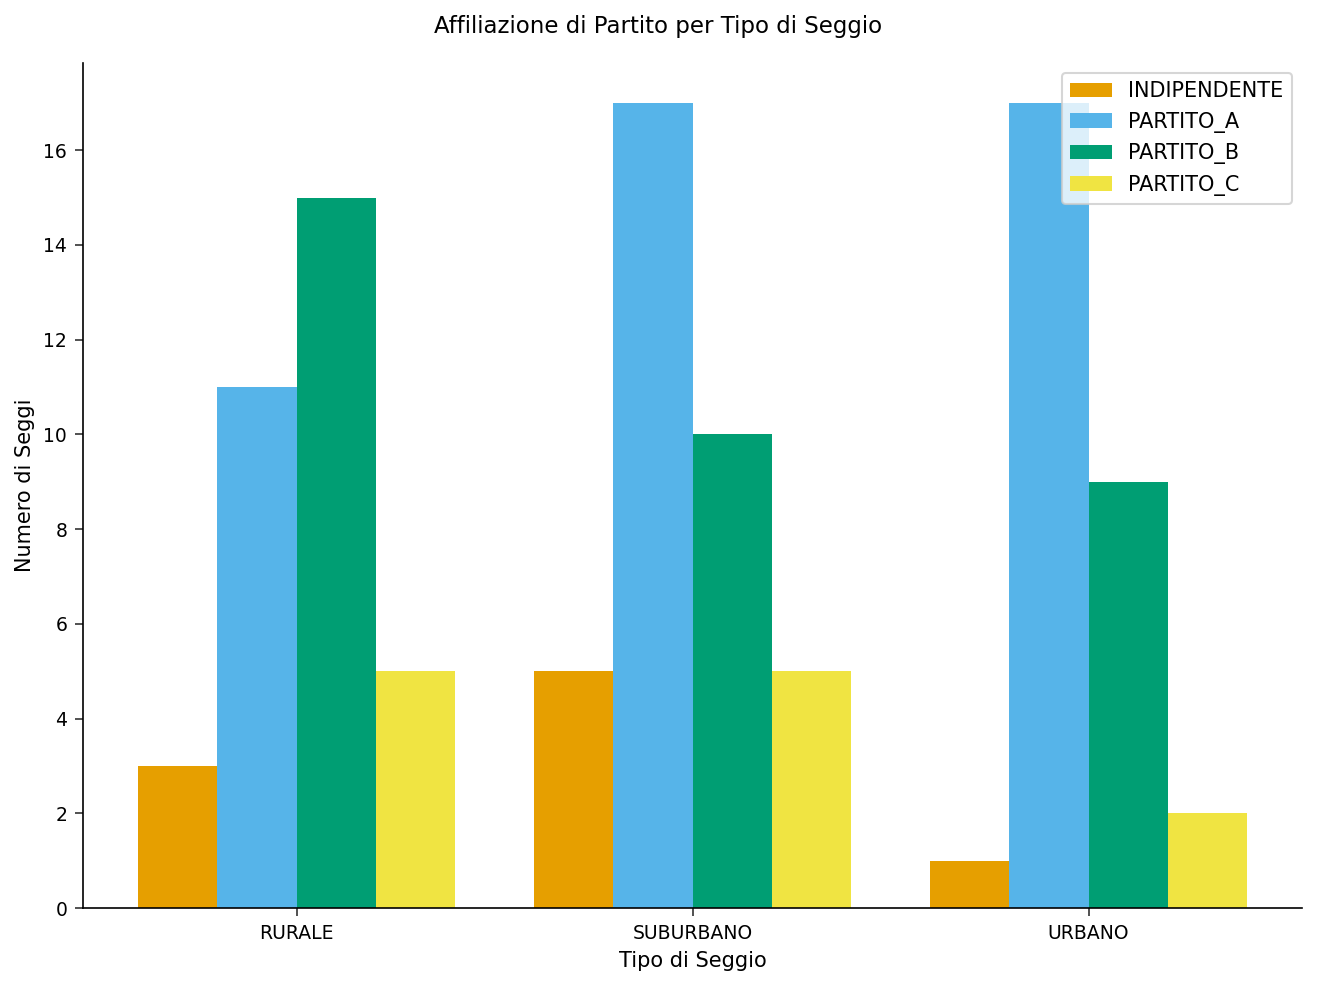

In [3]:
/* --------------------------------------------------------
   Affiliazione di partito per tipo di seggio (conteggio seggi)
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREQUENZE;
    XAXIS ETICHETTA='Tipo di Seggio';
    YAXIS ETICHETTA='Numero di Seggi';
    TITOLO 'Affiliazione di Partito per Tipo di Seggio';
ESEGUIRE;


---

                         Tipo di Seggio per Partito: Tabulazione Incrociata con Conteggi Attesi                         

                                                   The FREQ Procedure

Table of Tipo di Seggio by Partito

Tipo di Seggio |INDIPENDENTE |   PARTITO_A |   PARTITO_B |   PARTITO_C |        Total
---------------+-------------+-------------+-------------+-------------+-------------
RURALE         |           3 |          11 |          15 |           5 |           34
               |        3.00 |       11.00 |       15.00 |        5.00 |        34.00
               |        3.06 |       15.30 |       11.56 |        4.08 |             
               |        8.82 |       32.35 |       44.12 |       14.71 |       100.00
               |       33.33 |       24.44 |       44.12 |       41.67 |        34.00
---------------+-------------+-------------+-------------+-------------+-------------
SUBURBANO      |           5 |          17 |          10 |           5 |           


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


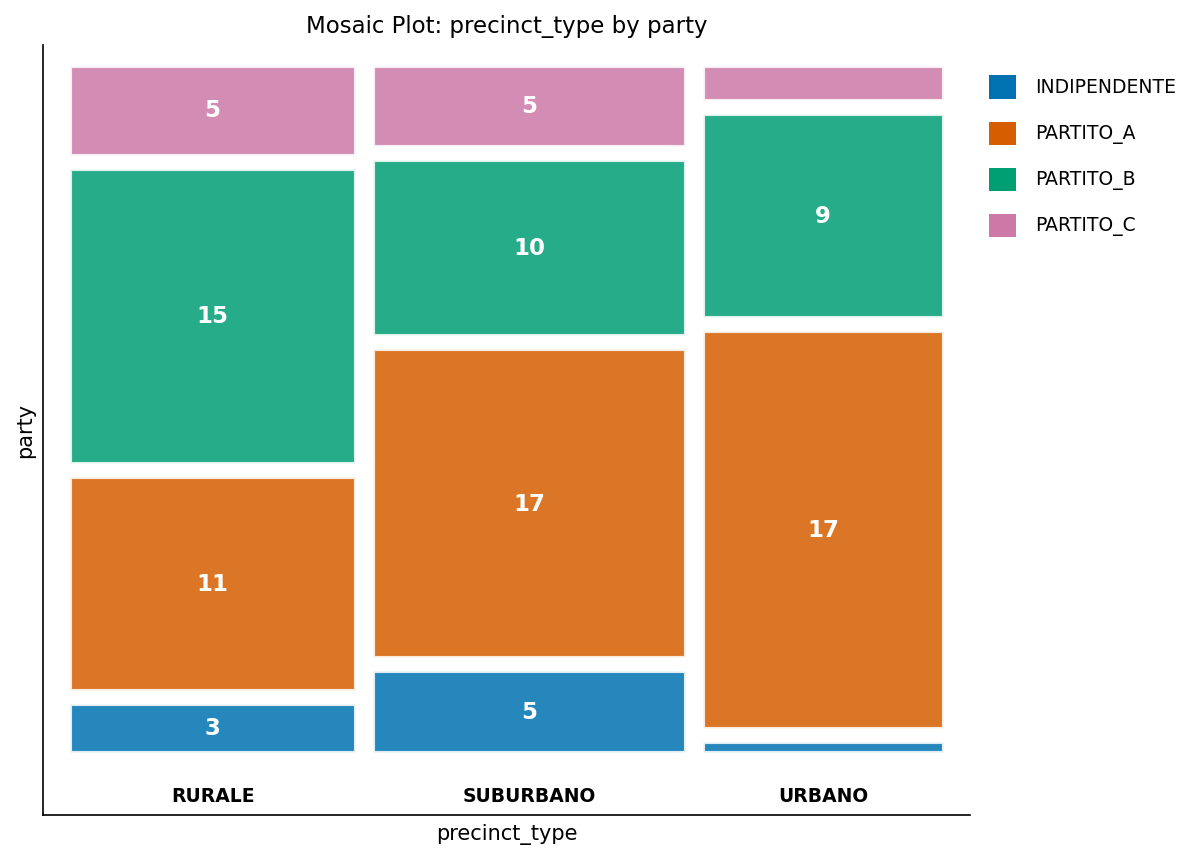

In [4]:
/* --------------------------------------------------------
   Tabulazione incrociata tipo di seggio x partito.
   Richiede i conteggi ATTESI cosi' le celle sparse sono
   visibili, piu' il test chi-quadrato asintotico di Pearson
   di associazione generale. Notare i conteggi attesi piccoli
   nelle colonne INDIPENDENTE e PARTITO_C -- il segnale che
   un test di tendenza ordinato ed esatto e' lo strumento
   inferenziale migliore.
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.precinct_votes;
    ETICHETTA precinct_type="Tipo di Seggio" party="Partito";
    TABLES precinct_type * party / chisq expected;
    TITOLO 'Tipo di Seggio per Partito: Tabulazione Incrociata con Conteggi Attesi';
ESEGUIRE;


                Test di Tendenza di Cochran-Armitage: Sostegno al Partito A Lungo il Gradiente dei Seggi                

                                                   The FREQ Procedure

Table of Gradiente Seggio by Sostegno Partito A

Gradiente Seggio |         0 |         1 |      Total
-----------------+-----------+-----------+-----------
1                |        12 |        17 |         29
                 |     12.00 |     17.00 |      29.00
                 |     41.38 |     58.62 |     100.00
                 |     21.82 |     37.78 |      29.00
-----------------+-----------+-----------+-----------
2                |        20 |        17 |         37
                 |     20.00 |     17.00 |      37.00
                 |     54.05 |     45.95 |     100.00
                 |     36.36 |     37.78 |      37.00
-----------------+-----------+-----------+-----------
3                |        23 |        11 |         34
                 |     23.00 |     11.00 |      34.00
  


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


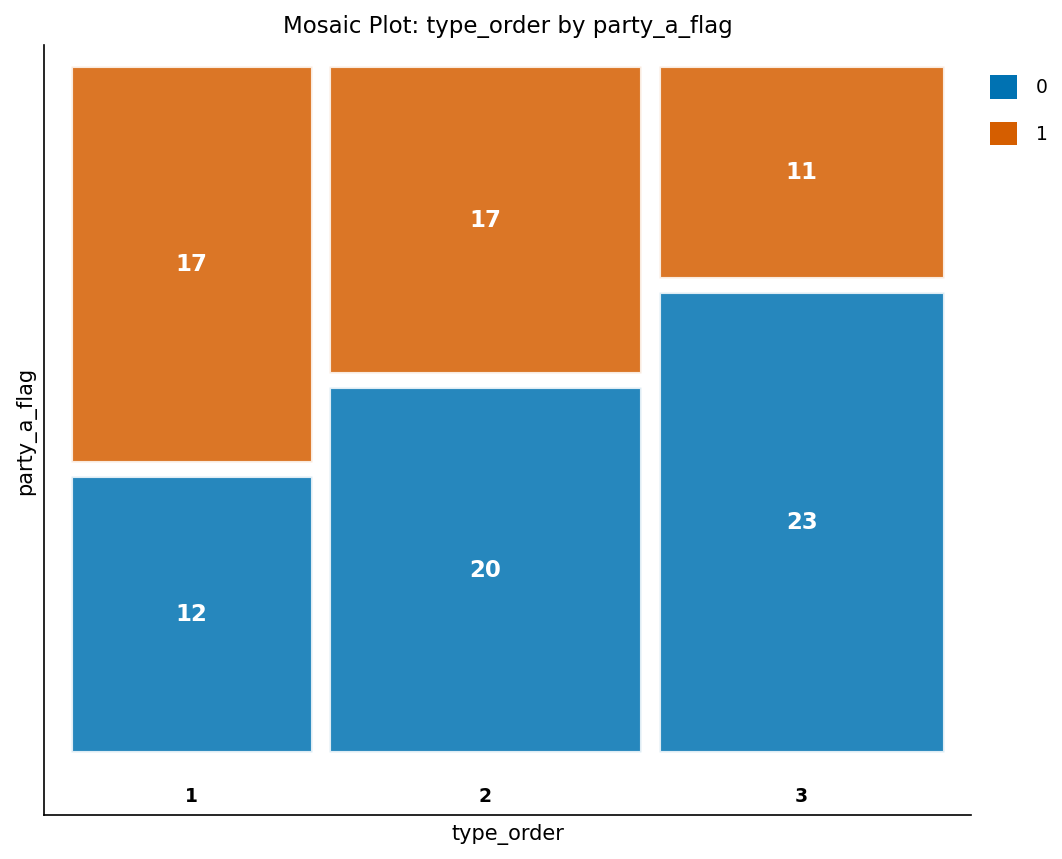

In [5]:
/* --------------------------------------------------------
   Test di tendenza di Cochran-Armitage. Ricodifica il tipo
   di seggio in un punteggio ordinale (1=Urbano, 2=Suburbano,
   3=Rurale) e verifica se il sostegno al Partito A mostra una
   tendenza monotona lungo il gradiente. EXACT TREND richiede
   il p-value esatto, appropriato date le piccole dimensioni
   di cella.
   -------------------------------------------------------- */
DATI work.precinct_ordinal;
    IMPOSTARE work.precinct_votes;
    /* Codifica ordinale: 1=Urbano, 2=Suburbano, 3=Rurale */
    SE_COND precinct_type = 'URBANO' ALLORA type_order = 1;
    ALTRIMENTI SE_COND precinct_type = 'SUBURBANO' ALLORA type_order = 2;
    ALTRIMENTI type_order = 3;
    /* Esito binario: Partito A rispetto a tutte le altre affiliazioni */
    party_a_flag = (party = 'PARTITO_A');
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.precinct_ordinal;
    ETICHETTA type_order="Gradiente Seggio" party_a_flag="Sostegno Partito A";
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    TITOLO 'Test di Tendenza di Cochran-Armitage: Sostegno al Partito A Lungo il Gradiente dei Seggi';
ESEGUIRE;


                                      Distribuzione del Tipo di Seggio per Contea                                       

                                                   The FREQ Procedure

Table of Contea by Tipo di Seggio

Contea    |    RURALE | SUBURBANO |    URBANO |      Total
----------+-----------+-----------+-----------+-----------
ADAMS     |         5 |        10 |         4 |         19
          |      5.00 |     10.00 |      4.00 |      19.00
          |     26.32 |     52.63 |     21.05 |     100.00
          |     14.71 |     27.03 |     13.79 |      19.00
----------+-----------+-----------+-----------+-----------
HAMILTON  |         7 |         7 |         7 |         21
          |      7.00 |      7.00 |      7.00 |      21.00
          |     33.33 |     33.33 |     33.33 |     100.00
          |     20.59 |     18.92 |     24.14 |      21.00
----------+-----------+-----------+-----------+-----------
JEFFERSON |         4 |         7 |         7 |         18
     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


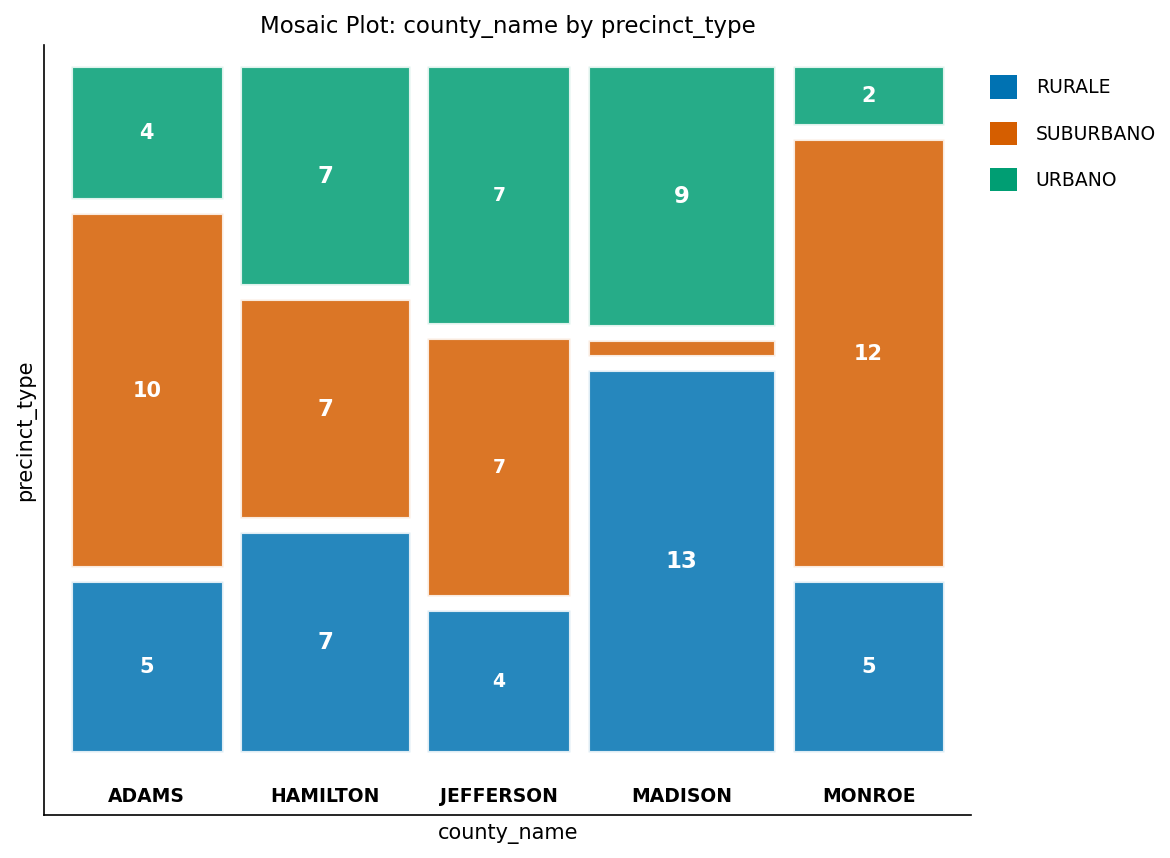

In [6]:
/* --------------------------------------------------------
   Vista a livello di contea: come varia il mix urbano/
   suburbano/rurale tra le cinque contee. Contestualizza il
   risultato della tendenza -- il gradiente di seggio e'
   presente in ogni contea, ma la sua composizione differisce.
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.precinct_votes;
    ETICHETTA county_name="Contea" precinct_type="Tipo di Seggio";
    TABLES county_name * precinct_type / nocum;
    TITOLO 'Distribuzione del Tipo di Seggio per Contea';
ESEGUIRE;


---

### Interpretazione

Sui 100 seggi, il Partito A detiene una maggioranza relativa complessiva
(45 seggi), seguito dal Partito B (34), dal Partito C (12) e dagli
Indipendenti (9). La tabulazione incrociata mostra che la quota del
Partito A segue un chiaro gradiente urbano-rurale: rappresenta il 58,6%
dei seggi urbani, il 46,0% dei seggi suburbani e il 32,4% dei seggi
rurali, mentre il Partito B si muove nella direzione opposta, salendo dal
31,0% urbano al 44,1% rurale.

Il test chi-quadrato onnicomprensivo di Pearson di associazione generale
**non** è statisticamente significativo (chi-quadrato = 6,78, 6 gdl, p =
0,3418; V di Cramer = 0,18). Anche questo risultato è fragile: la
visualizzazione dei conteggi attesi rivela diverse celle sotto cinque —
per esempio, la colonna Indipendenti ha conteggi attesi di 3,06, 3,33 e
2,61, e gli Indipendenti urbani contano un solo seggio — quindi
l'approssimazione chi-quadrato per grandi campioni non è affidabile in
questo caso.

Il test di tendenza di Cochran-Armitage affina la domanda usando la
codifica ordinale urbano-suburbano-rurale. Rileva il declino monotono nel
sostegno al Partito A che il test onnicomprensivo non coglie: chi-quadrato
di tendenza = 4,38 con un Pr > ChiSq asintotico = 0,0363 e un **Pr >= |Z|
esatto = 0,0431**, significativo al livello 0,05. Questo è il vantaggio
analitico — un test mirato, esatto, a un solo grado di libertà recupera
un segnale direzionale reale che il test di associazione generico a 6
gradi di libertà, indebolito dalle celle sparse, non individua.

La vista a livello di contea conferma che la suddivisione
urbano/suburbano/rurale è presente in tutte le cinque contee, sebbene il
mix differisca: Madison è la più rurale (13 seggi rurali su 23) mentre
Monroe è la più suburbana (12 su 19). Per la valutazione dell'impatto
della ridefinizione dei confini elettorali, il messaggio è che i
cambiamenti di confine che spostano i seggi lungo l'asse urbano-rurale
altererebbero in modo misurabile la composizione partitica, e che questa
tendenza geografica è meglio dimostrata dal test di tendenza esatto
piuttosto che dal chi-quadrato onnicomprensivo.


---

                                      Distribuzione del Tipo di Seggio per Contea                                       

                                                   The FREQ Procedure

Table of Tipo di Seggio by Partito

Tipo di Seggio |INDIPENDENTE |   PARTITO_A |   PARTITO_B |   PARTITO_C |        Total
---------------+-------------+-------------+-------------+-------------+-------------
RURALE         |           3 |          11 |          15 |           5 |           34
               |        3.00 |       11.00 |       15.00 |        5.00 |        34.00
               |        8.82 |       32.35 |       44.12 |       14.71 |       100.00
               |       33.33 |       24.44 |       44.12 |       41.67 |        34.00
---------------+-------------+-------------+-------------+-------------+-------------
SUBURBANO      |           5 |          17 |          10 |           5 |           37
               |        5.00 |       17.00 |       10.00 |        5.00 |        37.


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


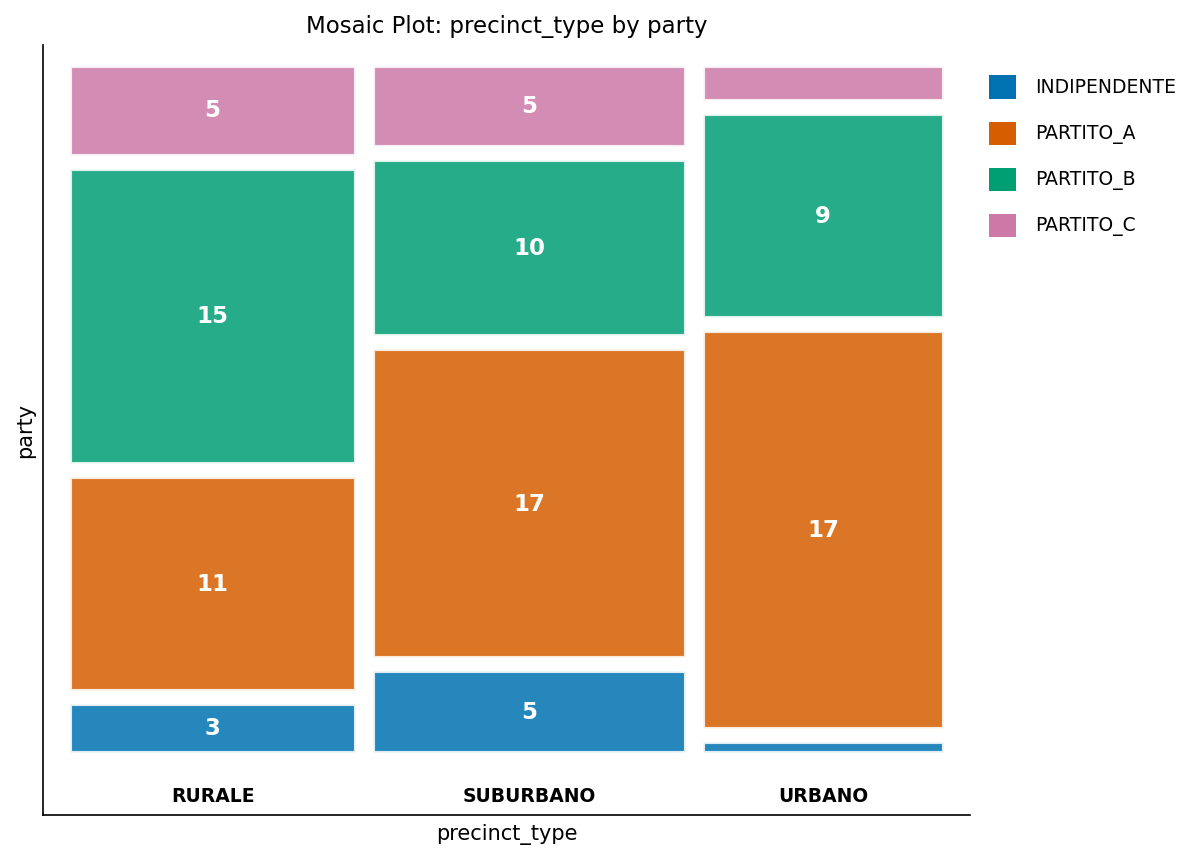

In [7]:
/* --------------------------------------------------------
   Esporta il riepilogo tipo di seggio x partito per la
   valutazione dell'impatto della ridefinizione dei confini
   elettorali a valle.
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.precinct_votes;
    ETICHETTA precinct_type="Tipo di Seggio" party="Partito";
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>